In [1]:
import numpy as np

# =========================
# 1. READ TSPLIB
# =========================
def read_tsp(file_path):
    coords = []
    start = False

    with open(file_path, 'r') as f:
        for line in f:
            if "NODE_COORD_SECTION" in line:
                start = True
                continue
            if "EOF" in line:
                break
            if start:
                parts = line.strip().split()
                if len(parts) >= 3:
                    x = float(parts[1])
                    y = float(parts[2])
                    coords.append([x, y])

    return np.array(coords)

# =========================
# 2. DISTANCE
# =========================
def distance(a, b):
    return np.linalg.norm(a - b)

# =========================
# 3. DECODE (random key)
# =========================
def decode(individual):
    return np.argsort(individual)

# =========================
# 4. TSP-D COST
# =========================
DRONE_RANGE = 800      # chỉnh theo dataset
TRUCK_SPEED = 1.0
DRONE_SPEED = 1.5

def tspd_cost(route, coords):
    total_time = 0.0
    i = 0

    while i < len(route) - 1:
        a = route[i]
        b = route[i+1]

        # thử dùng drone
        if i < len(route) - 2:
            c = route[i+2]

            truck_dist = distance(coords[a], coords[c])
            drone_dist = (
                distance(coords[a], coords[b]) +
                distance(coords[b], coords[c])
            )

            if drone_dist <= DRONE_RANGE:
                truck_time = truck_dist / TRUCK_SPEED
                drone_time = drone_dist / DRONE_SPEED

                total_time += max(truck_time, drone_time)
                i += 2
                continue

        # truck bình thường
        total_time += distance(coords[a], coords[b]) / TRUCK_SPEED
        i += 1

    return total_time

# =========================
# 5. DE ALGORITHM
# =========================
def DE_tspd(coords, NP=50, F=0.8, CR=0.9, GEN=300):

    N = len(coords)
    pop = np.random.rand(NP, N)

    def fitness(ind):
        route = decode(ind)
        return tspd_cost(route, coords)

    for g in range(GEN):
        for i in range(NP):
            idxs = [idx for idx in range(NP) if idx != i]
            r1, r2, r3 = pop[np.random.choice(idxs, 3, replace=False)]

            # mutation
            v = r1 + F * (r2 - r3)
            v = np.clip(v, 0, 1)

            # crossover
            u = np.copy(pop[i])
            j_rand = np.random.randint(N)

            for j in range(N):
                if np.random.rand() < CR or j == j_rand:
                    u[j] = v[j]

            # selection
            if fitness(u) < fitness(pop[i]):
                pop[i] = u

        if g % 50 == 0:
            best = min(pop, key=fitness)
            print(f"Gen {g}, Best = {fitness(best):.2f}")

    best = min(pop, key=fitness)
    return decode(best), fitness(best)

# =========================
# 6. MAIN
# =========================
if __name__ == "__main__":
    coords = read_tsp("berlin52.tsp")

    best_route, best_cost = DE_tspd(coords)

    print("\nBest route:", best_route)
    print("Best cost:", best_cost)

Gen 0, Best = 24627.74
Gen 50, Best = 19197.59
Gen 100, Best = 15745.43
Gen 150, Best = 14352.52
Gen 200, Best = 13999.37
Gen 250, Best = 13999.37

Best route: [12 13 10 11 25 26 27 31 45 39 36 48 33 28 46  3 24 35 14  9  5 47 37 15
  4 43 21 49  0 42  7  8 38 40 18 19 41 29 30  2  1  6 22 17 16 20 23 34
 44 32 50 51]
Best cost: 13999.365007406901


In [3]:
import numpy as np

# =========================
# 1. READ TSPLIB
# =========================
def read_tsp(file_path):
    coords = []
    start = False

    with open(file_path, 'r') as f:
        for line in f:
            if "NODE_COORD_SECTION" in line:
                start = True
                continue
            if "EOF" in line:
                break
            if start:
                parts = line.strip().split()
                if len(parts) >= 3:
                    x = float(parts[1])
                    y = float(parts[2])
                    coords.append([x, y])

    return np.array(coords)

# =========================
# 2. DISTANCE
# =========================
def distance(a, b):
    return np.linalg.norm(a - b)

# =========================
# 3. DECODE
# =========================
def decode(individual):
    return np.argsort(individual)

# =========================
# 4. TSP-D COST
# =========================
DRONE_RANGE = 2000
TRUCK_SPEED = 1.0
DRONE_SPEED = 2.0

def tspd_cost(route, coords):
    total_time = 0.0
    i = 0

    while i < len(route) - 1:
        a = route[i]
        b = route[i+1]

        if i < len(route) - 2:
            c = route[i+2]

            truck_dist = distance(coords[a], coords[c])
            drone_dist = (
                distance(coords[a], coords[b]) +
                distance(coords[b], coords[c])
            )

            if drone_dist <= DRONE_RANGE:
                truck_time = truck_dist / TRUCK_SPEED
                drone_time = drone_dist / DRONE_SPEED

                total_time += max(truck_time, drone_time)
                i += 2
                continue

        total_time += distance(coords[a], coords[b]) / TRUCK_SPEED
        i += 1

    return total_time

# =========================
# 5. 2-OPT (LOCAL SEARCH)
# =========================
def two_opt(route, coords):
    best = route.copy()
    improved = True

    while improved:
        improved = False
        for i in range(1, len(route)-2):
            for j in range(i+1, len(route)):
                if j - i == 1:
                    continue

                new_route = route.copy()
                new_route[i:j] = route[j-1:i-1:-1]

                if tspd_cost(new_route, coords) < tspd_cost(best, coords):
                    best = new_route
                    improved = True

        route = best

    return best

# =========================
# 6. DE ALGORITHM
# =========================
def DE_tspd(coords, NP=100, F=0.8, CR=0.9, GEN=1000):

    N = len(coords)
    pop = np.random.rand(NP, N)

    def fitness(ind):
        route = decode(ind)
        return tspd_cost(route, coords)

    best_global = None
    best_cost = float('inf')

    for g in range(GEN):
        for i in range(NP):
            idxs = [idx for idx in range(NP) if idx != i]
            r1, r2, r3 = pop[np.random.choice(idxs, 3, replace=False)]

            # Mutation
            v = r1 + F * (r2 - r3)
            v = np.clip(v, 0, 1)

            # Crossover
            u = np.copy(pop[i])
            j_rand = np.random.randint(N)

            for j in range(N):
                if np.random.rand() < CR or j == j_rand:
                    u[j] = v[j]

            # Selection
            if fitness(u) < fitness(pop[i]):
                pop[i] = u

        # ===== LẤY BEST =====
        best = min(pop, key=fitness)
        route = decode(best)

        # ===== LOCAL SEARCH =====
        route = two_opt(route, coords)
        cost = tspd_cost(route, coords)

        if cost < best_cost:
            best_cost = cost
            best_global = route.copy()

        if g % 50 == 0:
            print(f"Gen {g}, Best = {best_cost:.2f}")

    return best_global, best_cost

# =========================
# 7. MAIN
# =========================
if __name__ == "__main__":
    coords = read_tsp("berlin52.tsp")

    best_route, best_cost = DE_tspd(coords)

    print("\nBest route:", best_route)
    print("Best cost:", best_cost)

Gen 0, Best = 5967.85


KeyboardInterrupt: 

In [6]:
import numpy as np

# =========================
# 1. READ TSPLIB
# =========================
def read_tsp(file_path):
    coords = []
    start = False

    with open(file_path, 'r') as f:
        for line in f:
            if "NODE_COORD_SECTION" in line:
                start = True
                continue
            if "EOF" in line:
                break
            if start:
                parts = line.strip().split()
                coords.append([float(parts[1]), float(parts[2])])

    return np.array(coords)


# =========================
# 2. DISTANCE MATRIX
# =========================
def compute_dist_matrix(coords):
    N = len(coords)
    dist = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            dist[i][j] = np.linalg.norm(coords[i] - coords[j])
    return dist


# =========================
# 3. DECODE
# =========================
def decode(ind):
    return np.argsort(ind)


# =========================
# 4. TSP-D COST (IMPROVED)
# =========================
DRONE_RANGE = 200      # balanced
TRUCK_SPEED = 1.0
DRONE_SPEED = 1.5
WAIT_TIME = 5          # realistic delay

def tspd_cost(route, dist):
    total = 0.0
    i = 0
    N = len(route)

    while i < N - 1:
        a = route[i]
        b = route[i+1]

        if i < N - 2:
            c = route[i+2]

            truck_dist = dist[a][c]
            drone_dist = dist[a][b] + dist[b][c]

            # saving nếu dùng drone
            saving = dist[a][b] + dist[b][c] - dist[a][c]

            # chỉ dùng drone nếu:
            # - đủ range
            # - thực sự có lợi
            if drone_dist <= DRONE_RANGE and saving > 5:
                truck_time = truck_dist / TRUCK_SPEED
                drone_time = drone_dist / DRONE_SPEED

                total += max(truck_time, drone_time) + WAIT_TIME
                i += 2
                continue

        # truck bình thường
        total += dist[a][b] / TRUCK_SPEED
        i += 1

    return total


# =========================
# 5. FAST 2-OPT
# =========================
def two_opt(route, dist, max_iter=15):
    best = route.copy()
    best_cost = tspd_cost(best, dist)

    N = len(route)

    for _ in range(max_iter):
        improved = False

        for i in range(1, N - 2):
            for j in range(i + 2, N):
                new_route = best.copy()
                new_route[i:j] = best[j-1:i-1:-1]

                new_cost = tspd_cost(new_route, dist)

                if new_cost < best_cost:
                    best = new_route
                    best_cost = new_cost
                    improved = True

        if not improved:
            break

    return best


# =========================
# 6. DE ALGORITHM
# =========================
def DE_tspd(coords, NP=60, F=0.8, CR=0.9, GEN=400):

    N = len(coords)
    dist = compute_dist_matrix(coords)

    pop = np.random.rand(NP, N)
    fitness_vals = np.zeros(NP)

    # init fitness
    for i in range(NP):
        fitness_vals[i] = tspd_cost(decode(pop[i]), dist)

    best_idx = np.argmin(fitness_vals)
    best_global = pop[best_idx].copy()
    best_cost = fitness_vals[best_idx]

    for g in range(GEN):
        for i in range(NP):
            idxs = [idx for idx in range(NP) if idx != i]
            r1, r2, r3 = pop[np.random.choice(idxs, 3, replace=False)]

            # mutation
            v = r1 + F * (r2 - r3)
            v = np.clip(v, 0, 1)

            # crossover
            u = pop[i].copy()
            j_rand = np.random.randint(N)

            for j in range(N):
                if np.random.rand() < CR or j == j_rand:
                    u[j] = v[j]

            u_route = decode(u)
            u_cost = tspd_cost(u_route, dist)

            # selection
            if u_cost < fitness_vals[i]:
                pop[i] = u
                fitness_vals[i] = u_cost

        # ===== BEST =====
        best_idx = np.argmin(fitness_vals)
        route = decode(pop[best_idx])

        # ===== 2-OPT (thỉnh thoảng mới chạy) =====
        if g % 25 == 0:
            route = two_opt(route, dist, max_iter=10)
            cost = tspd_cost(route, dist)

            if cost < best_cost:
                best_cost = cost
                best_global = route.copy()

        if g % 50 == 0:
            print(f"Gen {g}, Best = {best_cost:.2f}")

    return best_global, best_cost


# =========================
# 7. MAIN
# =========================
if __name__ == "__main__":
    coords = read_tsp("berlin52.tsp")

    best_route, best_cost = DE_tspd(coords)

    print("\nBest route:", best_route)
    print("Best cost:", best_cost)

Gen 0, Best = 8103.49
Gen 50, Best = 7558.77
Gen 100, Best = 7558.77
Gen 150, Best = 7483.12
Gen 200, Best = 7448.13
Gen 250, Best = 7448.13
Gen 300, Best = 7448.13
Gen 350, Best = 7448.13

Best route: [ 1  6 41 29 28 22 19 49 15 43 33 34 35 48 31  0 21 17 30 20 16  2 44 18
 40  7  8  9 32 42  3 24  5  4 14 39 38 36 37 47 23 45 25 46 13 12 26 27
 11 50 10 51]
Best cost: 7448.126260225293


Gen 0, Best = 26807.41
Gen 50, Best = 20317.09
Gen 100, Best = 19355.54
Gen 150, Best = 18125.98
Gen 200, Best = 17307.80
Gen 250, Best = 17102.86
Gen 300, Best = 16945.32
Gen 350, Best = 16945.32
Gen 400, Best = 16753.42
Gen 450, Best = 16753.42
Gen 500, Best = 15996.37
Gen 550, Best = 7620.43
Gen 600, Best = 7620.43
Gen 650, Best = 7620.43
Gen 700, Best = 7620.43
Gen 750, Best = 7620.43
Gen 800, Best = 7620.43
Gen 850, Best = 7620.43
Gen 900, Best = 7620.43
Gen 950, Best = 7620.43
Gen 1000, Best = 7620.43
Gen 1050, Best = 7620.43
Gen 1100, Best = 7620.43
Gen 1150, Best = 7620.43
Gen 1200, Best = 7620.43
Gen 1250, Best = 7620.43
Gen 1300, Best = 7620.43
Gen 1350, Best = 7620.43
Gen 1400, Best = 7620.43
Gen 1450, Best = 7620.43
Gen 1500, Best = 7620.43
Gen 1550, Best = 7620.43
Gen 1600, Best = 7620.43
Gen 1650, Best = 7620.43
Gen 1700, Best = 7620.43
Gen 1750, Best = 7620.43
Gen 1800, Best = 7620.43
Gen 1850, Best = 7620.43
Gen 1900, Best = 7620.43
Gen 1950, Best = 7620.43
Gen 2000, Be

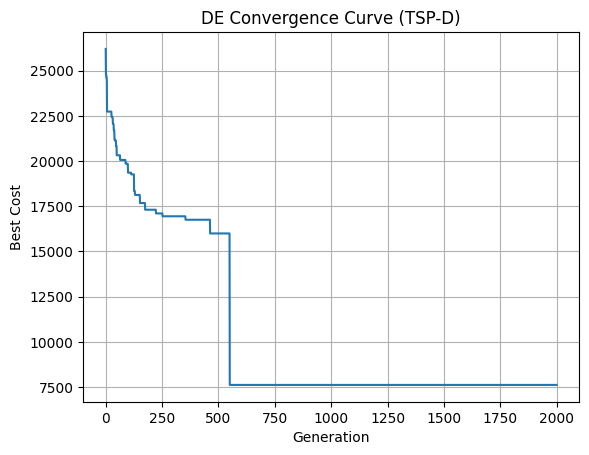

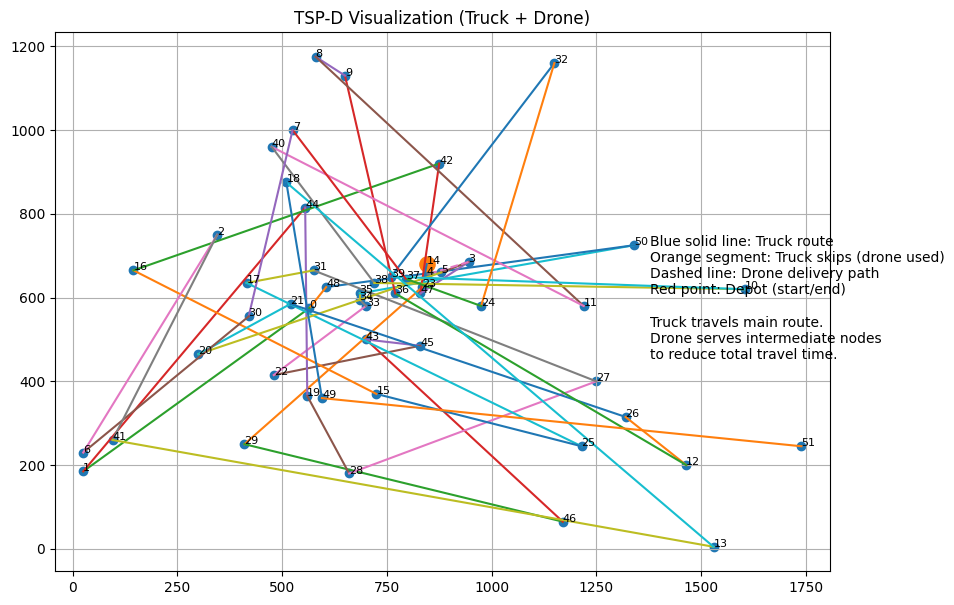

In [21]:
import numpy as np

# =========================
# READ TSPLIB
# =========================
def read_tsp(file_path):
    coords = []
    start = False

    with open(file_path, 'r') as f:
        for line in f:
            if "NODE_COORD_SECTION" in line:
                start = True
                continue
            if "EOF" in line:
                break
            if start:
                parts = line.strip().split()
                coords.append([float(parts[1]), float(parts[2])])

    return np.array(coords)


# =========================
# DIST MATRIX
# =========================
def compute_dist_matrix(coords):
    N = len(coords)
    dist = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            dist[i][j] = np.linalg.norm(coords[i] - coords[j])
    return dist


# =========================
# DECODE
# =========================
def decode(ind):
    return np.argsort(ind)


# =========================
# TSP-D COST
# =========================
DRONE_RANGE = 200
DRONE_SPEED = 1.5
TRUCK_SPEED = 1.0
WAIT_TIME = 5

def tspd_cost(route, dist):
    total = 0.0
    i = 0
    N = len(route)

    while i < N - 1:
        a = route[i]
        b = route[i+1]

        if i < N - 2:
            c = route[i+2]

            truck_dist = dist[a][c]
            drone_dist = dist[a][b] + dist[b][c]

            saving = dist[a][b] + dist[b][c] - dist[a][c]

            if drone_dist <= DRONE_RANGE and saving > 5:
                total += max(truck_dist/TRUCK_SPEED,
                             drone_dist/DRONE_SPEED) + WAIT_TIME
                i += 2
                continue

        total += dist[a][b]
        i += 1

    return total


# =========================
# 2-OPT
# =========================
def two_opt(route, dist, max_iter=10):
    best = route.copy()
    best_cost = tspd_cost(best, dist)

    for _ in range(max_iter):
        improved = False
        for i in range(1, len(route)-2):
            for j in range(i+2, len(route)):
                new_route = best.copy()
                new_route[i:j] = best[j-1:i-1:-1]

                new_cost = tspd_cost(new_route, dist)

                if new_cost < best_cost:
                    best = new_route
                    best_cost = new_cost
                    improved = True

        if not improved:
            break

    return best


# =========================
# DE MAIN
# =========================
def DE_tspd(coords, NP=60, F=0.8, CR=0.9, GEN=2000):

    dist = compute_dist_matrix(coords)
    N = len(coords)

    pop = np.random.rand(NP, N)
    fitness_vals = np.array([tspd_cost(decode(ind), dist) for ind in pop])

    best_idx = np.argmin(fitness_vals)
    best_cost = fitness_vals[best_idx]
    history = []
    best_sol = pop[best_idx].copy()

    print(f"Gen 0, Best = {best_cost:.2f}")

    for g in range(1, GEN + 1):
        for i in range(NP):
            idxs = [j for j in range(NP) if j != i]
            r1, r2, r3 = pop[np.random.choice(idxs, 3, replace=False)]

            v = np.clip(r1 + F * (r2 - r3), 0, 1)

            u = pop[i].copy()
            j_rand = np.random.randint(N)

            for j in range(N):
                if np.random.rand() < CR or j == j_rand:
                    u[j] = v[j]

            u_cost = tspd_cost(decode(u), dist)

            if u_cost < fitness_vals[i]:
                pop[i] = u
                fitness_vals[i] = u_cost

        # ===== UPDATE BEST =====
        idx = np.argmin(fitness_vals)
        if fitness_vals[idx] < best_cost:
            best_cost = fitness_vals[idx]
            best_sol = pop[idx].copy()
        history.append(best_cost)
        # ===== PHASE SWITCH =====
        # Sau 500 gen mới bật 2-opt
        if g > 500 and g % 50 == 0:
            route = decode(best_sol)
            route = two_opt(route, dist)
            cost = tspd_cost(route, dist)

            if cost < best_cost:
                best_cost = cost
                best_sol = route

        # ===== LOG =====
        if g % 50 == 0:
            print(f"Gen {g}, Best = {best_cost:.2f}")

    return decode(best_sol), best_cost, history

import matplotlib.pyplot as plt

def plot_convergence(history):
    plt.figure()
    plt.plot(history)
    plt.xlabel("Generation")
    plt.ylabel("Best Cost")
    plt.title("DE Convergence Curve (TSP-D)")
    plt.grid()
    plt.show()

def visualize_tspd(coords, route, dist):
    import matplotlib.pyplot as plt

    DRONE_RANGE = 200
    DRONE_SPEED = 1.5
    TRUCK_SPEED = 1.0
    WAIT_TIME = 5

    plt.figure(figsize=(10, 7))

    route_coords = coords[route]

    # ===== VẼ NODE =====
    plt.scatter(coords[:, 0], coords[:, 1])

    # depot
    plt.scatter(route_coords[0, 0], route_coords[0, 1], s=120)

    # ===== DUYỆT ROUTE =====
    i = 0
    N = len(route)

    while i < N - 1:
        a = route[i]
        b = route[i+1]

        if i < N - 2:
            c = route[i+2]

            truck_dist = dist[a][c]
            drone_dist = dist[a][b] + dist[b][c]
            saving = dist[a][b] + dist[b][c] - dist[a][c]

            # ===== DÙNG DRONE =====
            if drone_dist <= DRONE_RANGE and saving > 5:

                # 🚚 truck đi A → C (cam)
                plt.plot([coords[a][0], coords[c][0]],
                         [coords[a][1], coords[c][1]])

                # 🚁 drone đi A → B
                plt.plot([coords[a][0], coords[b][0]],
                         [coords[a][1], coords[b][1]],
                         linestyle='dashed')

                # 🚁 drone đi B → C
                plt.plot([coords[b][0], coords[c][0]],
                         [coords[b][1], coords[c][1]],
                         linestyle='dashed')

                i += 2
                continue

        # ===== TRUCK BÌNH THƯỜNG =====
        plt.plot([coords[a][0], coords[b][0]],
                 [coords[a][1], coords[b][1]])

        i += 1

    # ===== LABEL NODE =====
    for idx in route:
        x, y = coords[idx]
        plt.text(x, y, str(idx), fontsize=8)

    # ===== LEGEND GIẢI THÍCH =====
    explanation = (
        "Blue solid line: Truck route\n"
        "Orange segment: Truck skips (drone used)\n"
        "Dashed line: Drone delivery path\n"
        "Red point: Depot (start/end)\n\n"
        "Truck travels main route.\n"
        "Drone serves intermediate nodes\n"
        "to reduce total travel time."
    )

    plt.gcf().text(0.72, 0.5, explanation, fontsize=10, va='center')

    # ===== FORMAT =====
    plt.title("TSP-D Visualization (Truck + Drone)")
    plt.axis('equal')
    plt.grid()

    plt.show()
# =========================
# MAIN
# =========================
if __name__ == "__main__":
    coords = read_tsp("berlin52.tsp")

    best_route, best_cost, history = DE_tspd(coords)

    print("\nBest route:", best_route)
    print("Best cost:", best_cost)

    dist = compute_dist_matrix(coords)
    plot_convergence(history)
    visualize_tspd(coords, best_route, dist)